# Assignment 2: Transfer Learning Across Two Datasets

**Name:** Aydan Labowski

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [4]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: labowsax
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:22<00:00, 18.2MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [5]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

fire_images: 755 images (75.6%)
non_fire_images: 244 images (24.4%)
Total: 999
Majority-class baseline accuracy: 75.6%


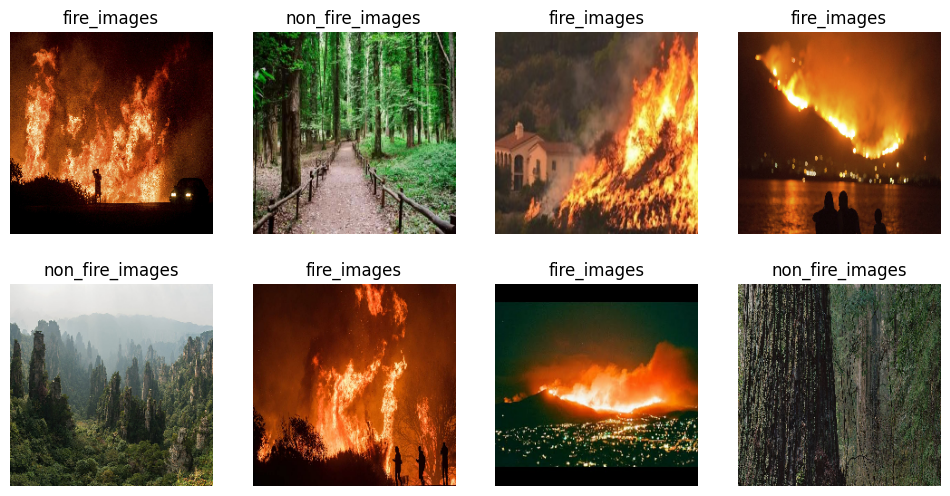

In [6]:
# Your exploration here
# Image counts
counts = {d: len(os.listdir(os.path.join(data_dir_fire, d)))
          for d in sorted(os.listdir(data_dir_fire))
          if os.path.isdir(os.path.join(data_dir_fire, d))}
total = sum(counts.values())
for k, v in counts.items():
    print(f"{k}: {v} images ({v/total:.1%})")
print(f"Total: {total}")
print(f"Majority-class baseline accuracy: {max(counts.values())/total:.1%}")

# Display images
images, labels = next(iter(train_raw_fire))
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names_fire[labels[i]])
    plt.axis("off")
plt.show()

*What did you notice about this dataset? Does it change how you'll approach the next steps?*

The dataset is greatly imbalanced. Roughly 75% of its images contain fire and only 25% without. This will skew the accuracy of the model in later steps.

## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [7]:
# Preprocess the data here
def prep(ds):
    return (ds.map(lambda x, y: (preprocess_input(x), y),
                   num_parallel_calls=tf.data.AUTOTUNE)
              .prefetch(tf.data.AUTOTUNE))

train_fire = prep(train_raw_fire)
val_fire   = prep(val_raw_fire)
test_fire  = prep(test_raw_fire)

In [8]:
# Build your model here
base_fire = MobileNetV2(weights="imagenet", include_top=False,
                        input_shape=img_size + (3,))
base_fire.trainable = False

inputs = tf.keras.Input(shape=img_size + (3,))
x = base_fire(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(1, activation="sigmoid")(x)

model_fire = Model(inputs, outputs)
model_fire.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# Compile your model here
model_fire.compile(optimizer="adam",
                   loss="binary_crossentropy",
                   metrics=["accuracy"])

## 1D — Train and Evaluate

In [10]:
# Train your model here
history_fire = model_fire.fit(train_fire, validation_data=val_fire, epochs=5)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.7129 - loss: 0.5324 - val_accuracy: 0.8345 - val_loss: 0.3503
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.9486 - loss: 0.1862 - val_accuracy: 0.9568 - val_loss: 0.1671
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.9700 - loss: 0.1202 - val_accuracy: 0.9640 - val_loss: 0.1222
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9771 - loss: 0.0965 - val_accuracy: 0.9640 - val_loss: 0.1047
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9829 - loss: 0.0832 - val_accuracy: 0.9712 - val_loss: 0.0914


In [11]:
# Report validation and test accuracy here
val_loss_fire,  val_acc_fire  = model_fire.evaluate(val_fire,  verbose=0)
test_loss_fire, test_acc_fire = model_fire.evaluate(test_fire, verbose=0)
print(f"Fire validation accuracy: {val_acc_fire:.4f}")
print(f"Fire test accuracy:       {test_acc_fire:.4f}")

Fire validation accuracy: 0.9568
Fire test accuracy:       0.9750


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

Class order: ['fire_images', 'non_fire_images']


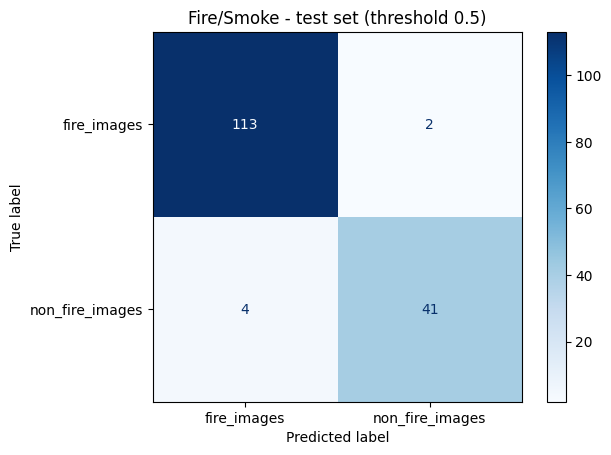

                 precision    recall  f1-score   support

    fire_images       0.97      0.98      0.97       115
non_fire_images       0.95      0.91      0.93        45

       accuracy                           0.96       160
      macro avg       0.96      0.95      0.95       160
   weighted avg       0.96      0.96      0.96       160

threshold | missed fires (FN) | false alarms (FP)
   0.5    |          2        |         4
   0.7    |          1        |         6
   0.9    |          1        |        13


In [12]:
# Build your confusion matrix here
from sklearn.metrics import classification_report

y_true, y_prob = [], []
for x, y in test_fire:
    y_true.append(y.numpy())
    y_prob.append(model_fire.predict(x, verbose=0).ravel())
y_true = np.concatenate(y_true)
y_prob = np.concatenate(y_prob)

print("Class order:", class_names_fire)

y_pred = (y_prob > 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names_fire).plot(cmap="Blues")
plt.title("Fire/Smoke - test set (threshold 0.5)")
plt.show()
print(classification_report(y_true, y_pred, target_names=class_names_fire))

print("threshold | missed fires (FN) | false alarms (FP)")
for t in [0.5, 0.7, 0.9]:
    pred = (y_prob > t).astype(int)
    fn = int(((y_true == 0) & (pred == 1)).sum())
    fp = int(((y_true == 1) & (pred == 0)).sum())
    print(f"   {t:.1f}    |        {fn:3d}        |       {fp:3d}")

*Your answer:* A false negative is more costly than a false positive. If a fire breaks out and it is not recognized, that could result in property damage and loss of life, both of which are far worse than sending out a crew on a false positive. I would then tune the threshold to accept more false alarms, just to be safe, by raising the cuttoff for predicting non-fire.




---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [13]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [14]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [15]:
# Preprocess the data here
train_sat = prep(train_raw_sat)
val_sat   = prep(val_raw_sat)
test_sat  = prep(test_raw_sat)
num_classes_sat = len(class_names_sat)
print("Number of classes:", num_classes_sat)

Number of classes: 10


In [16]:
# Build your model here
base_sat = MobileNetV2(weights="imagenet", include_top=False,
                       input_shape=img_size + (3,))
base_sat.trainable = False

inputs = tf.keras.Input(shape=img_size + (3,))
x = base_sat(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(num_classes_sat, activation="softmax")(x)   # one unit per class

model_sat = Model(inputs, outputs)
model_sat.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
# Compile your model here
model_sat.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

## 2C — Train and Evaluate

In [18]:
# Train your model here
history_sat = model_sat.fit(train_sat, validation_data=val_sat, epochs=5)

Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 919s 2s/step - accuracy: 0.8824 - loss: 0.3680 - val_accuracy: 0.9289 - val_loss: 0.2159
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 919s 2s/step - accuracy: 0.9334 - loss: 0.1954 - val_accuracy: 0.9356 - val_loss: 0.1898
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 901s 2s/step - accuracy: 0.9466 - loss: 0.1592 - val_accuracy: 0.9383 - val_loss: 0.1872
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 883s 1s/step - accuracy: 0.9535 - loss: 0.1382 - val_accuracy: 0.9418 - val_loss: 0.1801
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 929s 2s/step - accuracy: 0.9612 - loss: 0.1213 - val_accuracy: 0.9410 - val_loss: 0.1796


In [19]:
# Report validation and test accuracy here
val_loss_sat,  val_acc_sat  = model_sat.evaluate(val_sat,  verbose=0)
test_loss_sat, test_acc_sat = model_sat.evaluate(test_sat, verbose=0)
print(f"EuroSAT validation accuracy: {val_acc_sat:.4f}")
print(f"EuroSAT test accuracy:       {test_acc_sat:.4f}")

EuroSAT validation accuracy: 0.9398
EuroSAT test accuracy:       0.9375


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

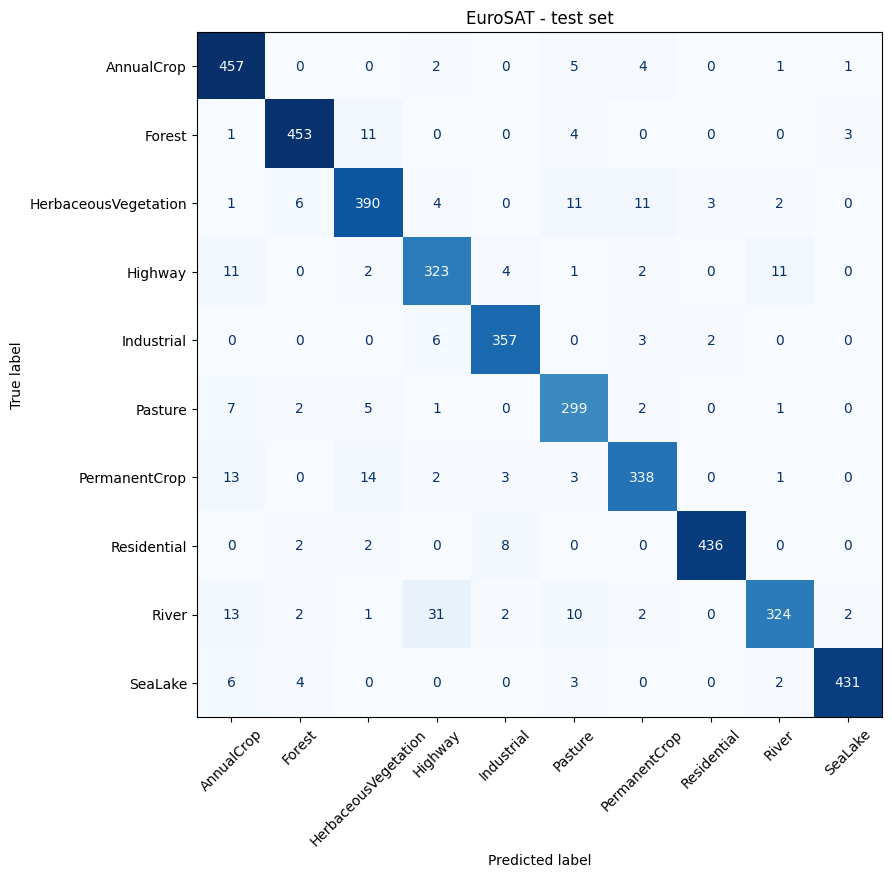

Most common confusions (count, true -> predicted):
   31  River -> Highway
   14  PermanentCrop -> HerbaceousVegetation
   13  River -> AnnualCrop
   13  PermanentCrop -> AnnualCrop
   11  Highway -> River
   11  Highway -> AnnualCrop


In [20]:
# Build your confusion matrix here
y_true_sat, y_pred_sat = [], []
for x, y in test_sat:
    y_true_sat.append(y.numpy())
    y_pred_sat.append(np.argmax(model_sat.predict(x, verbose=0), axis=1))
y_true_sat = np.concatenate(y_true_sat)
y_pred_sat = np.concatenate(y_pred_sat)

cm_sat = confusion_matrix(y_true_sat, y_pred_sat)
fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(cm_sat, display_labels=class_names_sat).plot(
    ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("EuroSAT - test set")
plt.tight_layout()
plt.show()

errors = [(cm_sat[i, j], class_names_sat[i], class_names_sat[j])
          for i in range(num_classes_sat) for j in range(num_classes_sat) if i != j]
print("Most common confusions (count, true -> predicted):")
for n, t, p in sorted(errors, reverse=True)[:6]:
    print(f"  {n:3d}  {t} -> {p}")

*Your answer:* The most common mistakes are between classes that look alike from above, typically Highway vs. River, Pasture vs. Herbaceous Vegetation, Annual Crop vs. Permanent Crop vs. Pasture, and sometimes Residential vs. Industrial. This makes visual sense: highways and rivers are both long, thin, winding strips; pasture, herbaceous vegetation, and the crop classes are all green fields that differ mainly in subtle texture and row patterns, which are hard to see in 64x64 images blown up to 224x224.




---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy |96% |94% |
| Test Accuracy |98% |94% |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*
1. Fire/Smoke is the closer match; EuroSAT is the bigger mismatch. The fire images are ground-level photos of scenes and objects (flames, forests, rooms), the same kind of imagery ImageNet is made of, so the frozen features (edges, textures, colors, simple shapes) transfer well. EuroSAT images are top-down satellite tiles at 64x64 pixels that are upscaled, with no recognizable "objects" in the ImageNet sense, only textures and layouts. My results reflect this: the fire model reached 96% validation and 98% test accuracy, while EuroSAT reached 94% and 94%.
2. Yes for both, but it should matter more for EuroSAT. Fine-tuning (unfreezing the top layers of MobileNetV2 with a low learning rate) lets the later layers specialize. The fire model is already strong because its domain matches ImageNet, so I'd expect only a small gain there, and with a tiny dataset there's also a risk of overfitting. EuroSAT has a large domain shift (overhead view, different textures), and its mistakes come from fine-grained texture differences that ImageNet's high-level features weren't built to separate. Adapting the later layers to those patterns should give a noticeably larger improvement.



---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*
1. The Fire dataset is imbalanced (about 75% fire), so I treated the majority-class baseline as the number to beat and relied on the confusion matrix and recall instead of accuracy alone, and I noted that the small, random, non-stratified test split makes the results noisy.
2. In Part 1 the task is binary, so I used a single sigmoid output unit with binary cross-entropy, which gives one probability for the positive class. In Part 2 there are 10 mutually exclusive land-use classes, so I used 10 output units with softmax (probabilities that sum to 1) and sparse categorical cross-entropy because the labels are integers. The difference exists because the loss and activation have to match how many classes there are and whether they're mutually exclusive.
3. A pretrained model's usefulness depends on both the quality of the model and how well its original training matches the new task. The same frozen MobileNetV2 worked very well on the Fire photos, which resemble ImageNet, but left more errors on EuroSAT satellite tiles, where the features were a poorer fit, so the model's quality alone did not decide the outcome.


---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.